## Importing the Libraries

In [ ]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
import lightgbm as lgb

from skimage.feature import graycomatrix, graycoprops
from scipy.stats import skew, kurtosis

## Target Catagories(Blowhole,Break,Crack,Fray,Free)

In [2]:
path = r"C:\Users\pabhi\OneDrive\Desktop\miniproject\B5. Magnetic-Tile-Defect\Magnetic-Tile-Defect"
MODEL_DIR = "models"
RESULTS_DIR = "results"
IMG_SIZE = (64, 64)

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

categories = sorted([
    d for d in os.listdir(path)
    if os.path.isdir(os.path.join(path, d)) and not d.startswith('.')
])


print("Detected classes:", categories)

Detected classes: ['MT_Blowhole', 'MT_Break', 'MT_Crack', 'MT_Fray', 'MT_Free']


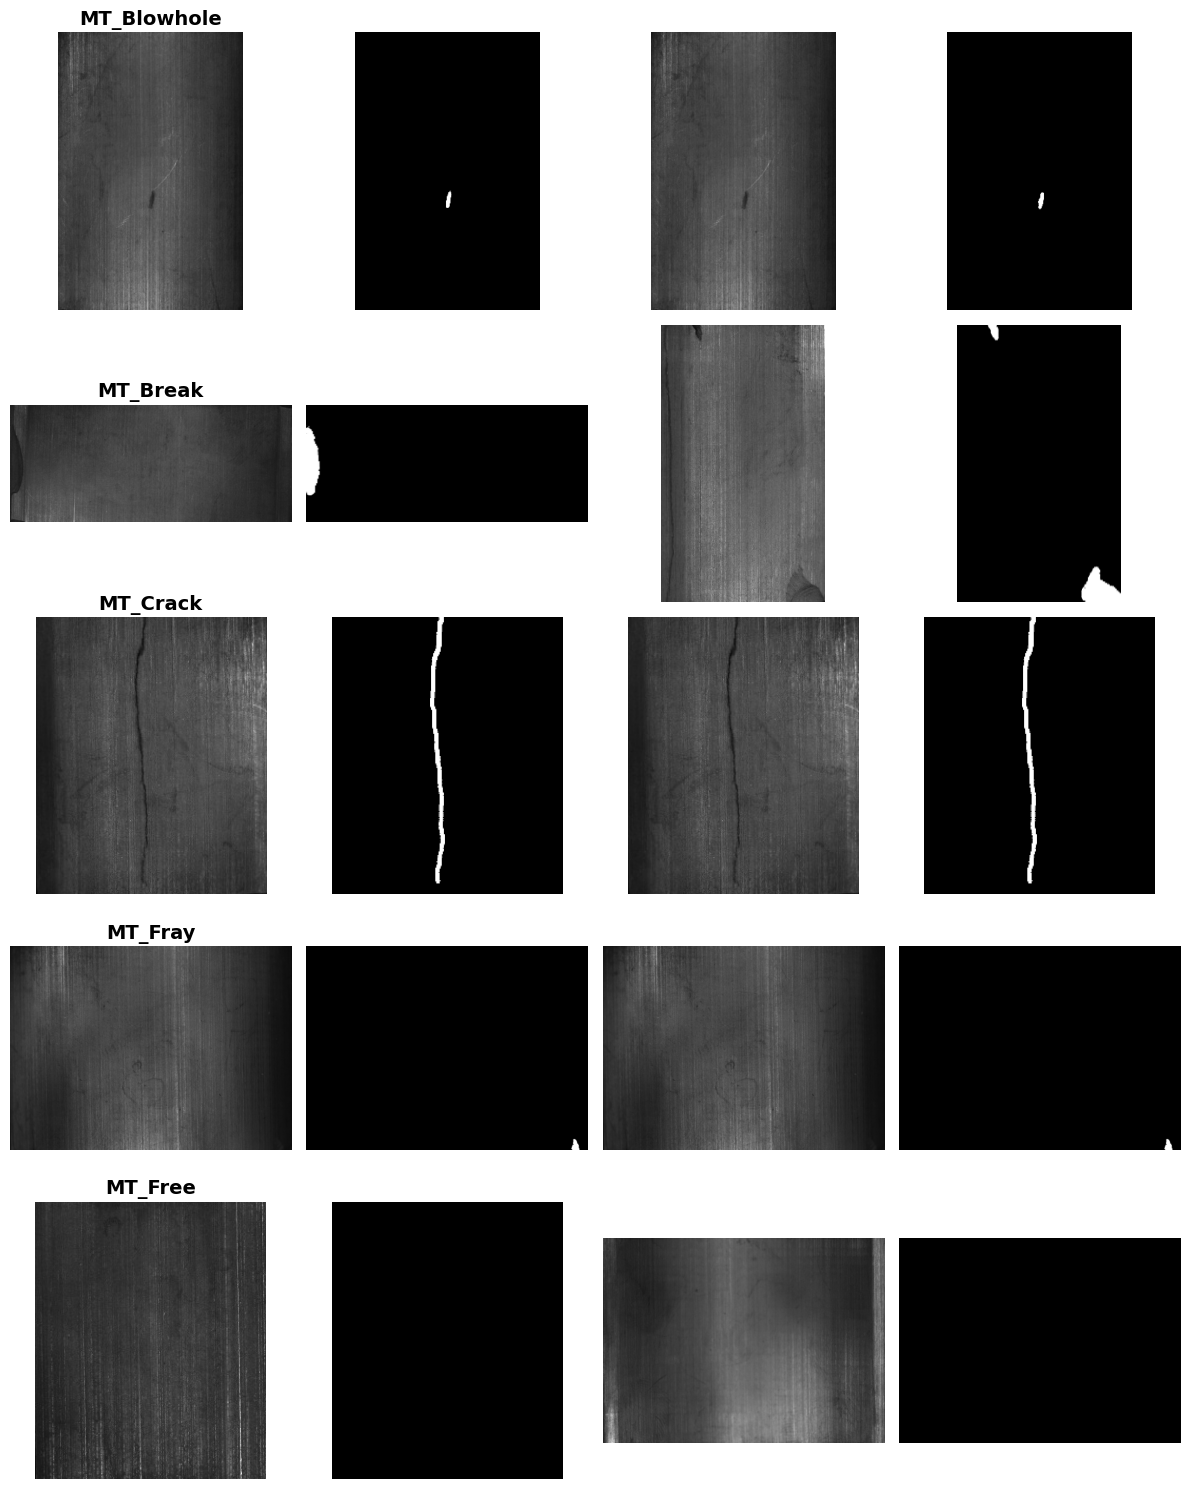

In [3]:
num_classes = len(categories)
num_cols = 4

plt.figure(figsize=(num_cols * 3, num_classes * 3))

for i, category in enumerate(categories):
    folder = os.path.join(path, category)
    images = [f for f in os.listdir(folder) if f.lower().endswith(('jpg','png','jpeg'))][:4]

    for j, img_name in enumerate(images):
        img = cv2.imread(os.path.join(folder, img_name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        ax = plt.subplot(num_classes, num_cols, i*num_cols + j + 1)
        ax.imshow(img)
        ax.axis("off")

        if j == 0:
            ax.set_title(category, fontsize=14, weight='bold')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "classes_grid.png"), dpi=300)
plt.show()


## Feature Extraction(GLCM+Statistics)

In [4]:
def extract_features(img):
    img = cv2.resize(img, IMG_SIZE)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    pixels = gray.flatten().astype(np.float32)

    # Statistical features
    mean_val = np.mean(pixels)  # Average brightness of the image
    std_val = np.std(pixels)  # Measures contrast
    skew_val = skew(pixels)  # Measures asymmetry of pixel intensity distribution
    kurt_val = kurtosis(pixels) # Measures tailedness of distribution (extreme pixel or not)
    energy_val = np.mean(pixels ** 2) # Measures overall intensity strength

    # GLCM
    glcm = graycomatrix(
        gray,
        distances=[1],
        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
        levels=256,
        symmetric=True,
        normed=True
    )

    contrast = graycoprops(glcm, 'contrast').mean() # Measures local intensity variation
    homogeneity = graycoprops(glcm, 'homogeneity').mean()  # Measures closeness of pixel pairs
    correlation = graycoprops(glcm, 'correlation').mean() # Measures how correlated a pixel is to its neighbor
    dissimilarity = graycoprops(glcm, 'dissimilarity').mean() # Similar to contrast, but linear
    asm = graycoprops(glcm, 'ASM').mean() # Measures uniformity

    return np.array([
        mean_val, std_val, skew_val, kurt_val,
        energy_val, contrast, dissimilarity,
        homogeneity, correlation, asm
    ], dtype=np.float32)


## X and Y Separation

In [5]:
X_file = os.path.join(MODEL_DIR, "X.npy")
Y_file = os.path.join(MODEL_DIR, "Y.npy")

if os.path.exists(X_file) and os.path.exists(Y_file):
    X = np.load(X_file)
    Y = np.load(Y_file)
    print("Loaded cached features.")
else:
    X, Y = [], []

    for root, _, files in os.walk(path):
        label = os.path.basename(root)
        if label not in categories:
            continue

        for file in files:
            if file.lower().endswith(('jpg','png','jpeg')):
                print(root)
                img = cv2.imread(os.path.join(root, file))
                features = extract_features(img)
                X.append(features)
                Y.append(categories.index(label))

    X = np.array(X)
    Y = np.array(Y)
    np.save(X_file, X)
    np.save(Y_file, Y)

print("Feature matrix:", X.shape)


Loaded cached features.
Feature matrix: (2621, 10)


In [6]:
df = pd.DataFrame(X)
df['Labels'] = Y
df

,0,1,2,3,4,5,6,7,8,9,Labels
0,70.036133,18.753716,0.001812,0.323988,5256.761719,57.733292,5.236198,0.200526,0.914722,0.000999,0
1,0.251953,7.335334,32.606731,1098.169189,53.870605,78.129723,0.380893,0.997323,0.292109,0.994381,0
2,69.159180,18.911146,-0.014006,0.251707,5140.623535,56.761890,5.214740,0.200167,0.917591,0.000988,0
3,0.337158,8.523139,26.879505,740.623901,72.757568,91.515709,0.454058,0.997002,0.385901,0.993882,0
4,68.168945,14.756413,1.352674,6.193400,4864.756836,125.758644,6.691219,0.183305,0.702780,0.001387,0
...,...,...,...,...,...,...,...,...,...,...,...
2616,59.037354,15.480499,0.292249,0.802349,3725.054932,42.400646,4.472759,0.237346,0.906418,0.001626,4
2617,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,4
2618,59.125732,16.139242,0.325270,1.172575,3756.327393,77.670166,5.102636,0.234429,0.842397,0.001647,4
2619,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,4


In [7]:
df.Labels.unique()

array([0, 1, 2, 3, 4])

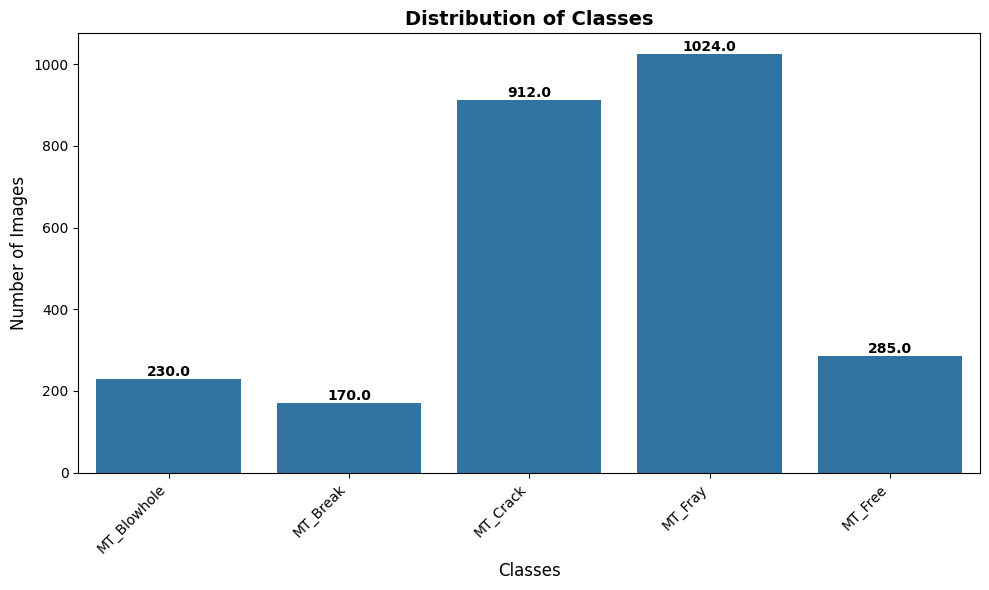

In [8]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(x=Y)

# Replace x-ticks with class names automatically
ax.set_xticklabels(categories, rotation=45, ha='right')

# Add value labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xlabel("Classes", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.title("Distribution of Classes", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

## Train_Test_Split

In [9]:
# Replace NaNs with column mean
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

# Now SMOTE will work
x_train, x_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=77, stratify=Y
)

from imblearn.over_sampling import SMOTE
sm = SMOTE()
x_train, y_train = sm.fit_resample(x_train, y_train)

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)


x_train: (4095, 10)
y_train: (4095,)


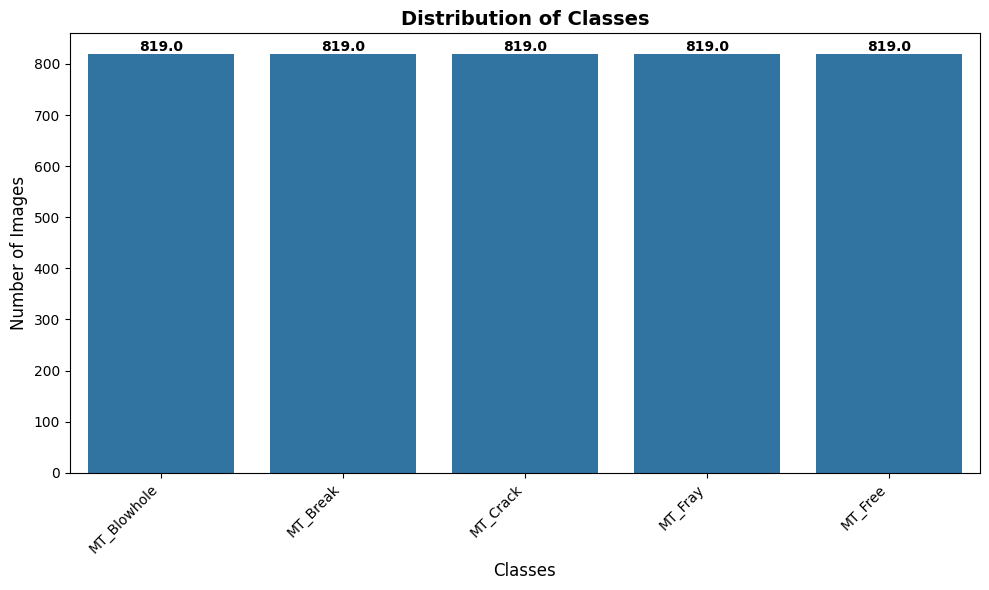

In [10]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(x=y_train)

# Replace x-ticks with class names automatically
ax.set_xticklabels(categories, rotation=45, ha='right')

# Add value labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xlabel("Classes", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.title("Distribution of Classes", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

## Performance Evaluation

In [11]:

# ──────────────────────────────────────────────────────────────
# Global containers
# ──────────────────────────────────────────────────────────────
metrics_overall = []                    # Overall metrics
class_metrics_storage = {}              # Key = class name → list of dicts (one per model)
def calculateMetrics(algorithm, predict, testY):
    """
    Call this for every model (RFC, DTC, NBC, etc.)
    """
    testY = testY.astype('int')
    predict = predict.astype('int')
    
    # ── Overall metrics ─────────────────────────────────────
    acc  = accuracy_score(testY, predict) * 100
    prec = precision_score(testY, predict, average='macro', zero_division=0) * 100
    rec  = recall_score(testY, predict, average='macro', zero_division=0) * 100
    f1   = f1_score(testY, predict, average='macro', zero_division=0) * 100
    
    metrics_overall.append({
        'Model': algorithm,
        'Accuracy':  round(acc, 2),
        'Precision': round(prec, 2),
        'Recall':    round(rec, 2),
        'F1-Score':  round(f1, 2)
    })
    
    print(f"\n=== {algorithm} Overall ===")
    print(f"Accuracy  : {acc:.2f}%")
    print(f"Precision : {prec:.2f}%")
    print(f"Recall    : {rec:.2f}%")
    print(f"F1-Score  : {f1:.2f}%\n")
    
    # ── Class-wise metrics ──────────────────────────────────
    report = classification_report(testY, predict, target_names=categories,
                                  output_dict=True, zero_division=0)
    print("\n=== Classification Report ===")
    print(classification_report(testY, predict, target_names=categories, zero_division=0))

    for cls in categories:
        # Initialize list for this class if first time
        if cls not in class_metrics_storage:
            class_metrics_storage[cls] = []
        
        class_metrics_storage[cls].append({
            'Model':     algorithm,
            'Precision': round(report[cls]['precision'] * 100, 2),
            'Recall':    round(report[cls]['recall'] * 100, 2),
            'F1-Score':  round(report[cls]['f1-score'] * 100, 2)
        })
    
    # ── Confusion matrix ────────────────────────────────────
    cm = confusion_matrix(testY, predict)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=categories, yticklabels=categories, cbar=False)
    plt.title(f"{algorithm} - Confusion Matrix")
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

## Model Building and Testing

## Ridge_Classifier


=== Ridge Classifier Overall ===
Accuracy  : 48.19%
Precision : 50.22%
Recall    : 54.05%
F1-Score  : 45.36%


=== Classification Report ===
              precision    recall  f1-score   support

 MT_Blowhole       0.27      0.46      0.34        46
    MT_Break       0.11      0.44      0.18        34
    MT_Crack       0.78      0.46      0.58       183
     MT_Fray       0.87      0.38      0.52       205
     MT_Free       0.49      0.96      0.65        57

    accuracy                           0.48       525
   macro avg       0.50      0.54      0.45       525
weighted avg       0.69      0.48      0.52       525



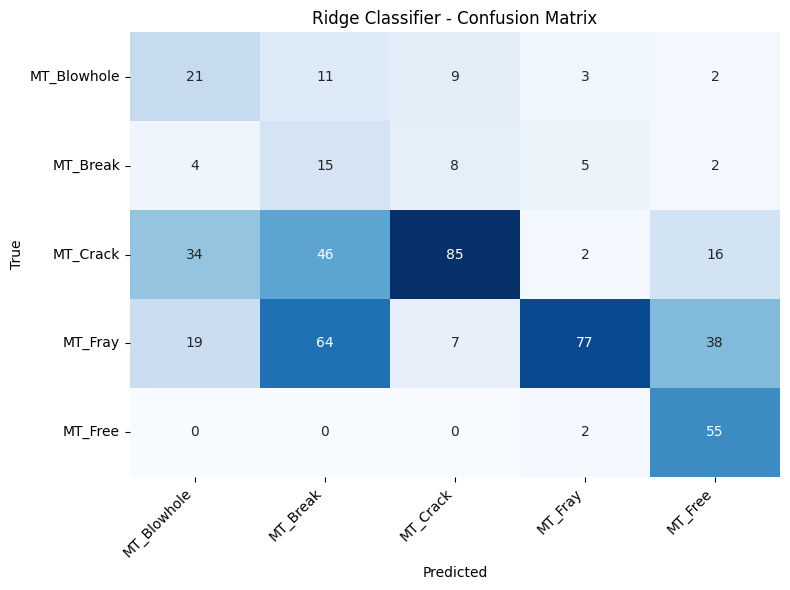

In [12]:
from sklearn.linear_model import RidgeClassifier
import os
import joblib

model_path = r"models\ridge_classifier.pkl"

os.makedirs(os.path.dirname(model_path), exist_ok=True)

if os.path.exists(model_path) and os.path.getsize(model_path) > 0:
    rid_clf = joblib.load(model_path)
    predict = rid_clf.predict(x_test)
    calculateMetrics("Ridge Classifier", predict, y_test)

else:
    rid_clf = RidgeClassifier(alpha=1.0)
    rid_clf.fit(x_train, y_train)
    predict = rid_clf.predict(x_test)
    joblib.dump(rid_clf, model_path)
    calculateMetrics("Ridge Classifier", predict, y_test)


## Quadratic_Discriminant_Analysis


=== QDA Classifier Overall ===
Accuracy  : 56.19%
Precision : 51.97%
Recall    : 59.29%
F1-Score  : 50.54%


=== Classification Report ===
              precision    recall  f1-score   support

 MT_Blowhole       0.25      0.65      0.36        46
    MT_Break       0.21      0.29      0.25        34
    MT_Crack       0.78      0.61      0.68       183
     MT_Fray       0.85      0.43      0.57       205
     MT_Free       0.51      0.98      0.67        57

    accuracy                           0.56       525
   macro avg       0.52      0.59      0.51       525
weighted avg       0.69      0.56      0.58       525



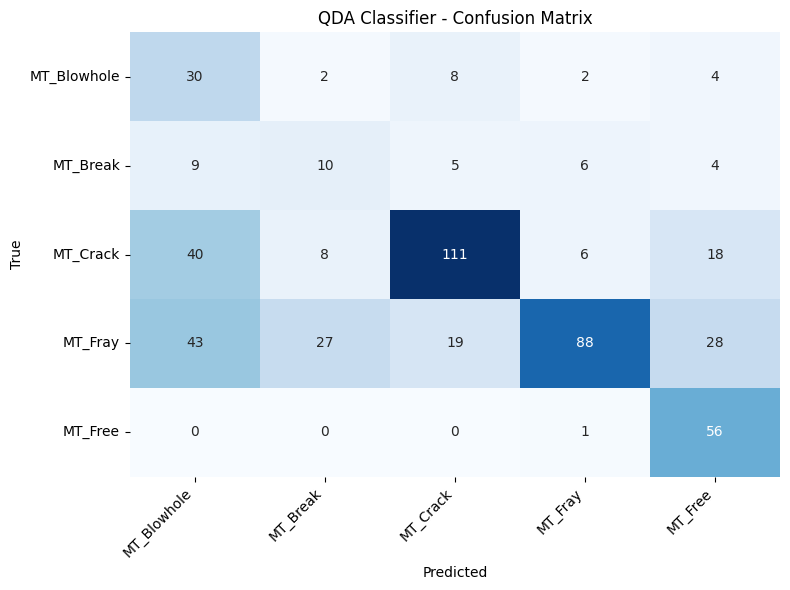

In [13]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
import os
import joblib

model_path = r"models\qda_classifier.pkl"

# Ensure folder exists
os.makedirs(os.path.dirname(model_path), exist_ok=True)

if os.path.exists(model_path) and os.path.getsize(model_path) > 0:
    qda_clf = joblib.load(model_path)
    predict = qda_clf.predict(x_test)
    calculateMetrics("QDA Classifier", predict, y_test)

else:
    qda_clf = QuadraticDiscriminantAnalysis()
    qda_clf.fit(x_train, y_train)
    predict = qda_clf.predict(x_test)
    joblib.dump(qda_clf, model_path)
    calculateMetrics("QDA Classifier", predict, y_test)


## K_Nearest_Neighbors_Classifier


=== KNN Classifier Overall ===
Accuracy  : 90.48%
Precision : 80.71%
Recall    : 76.81%
F1-Score  : 78.50%


=== Classification Report ===
              precision    recall  f1-score   support

 MT_Blowhole       0.65      0.52      0.58        46
    MT_Break       0.58      0.53      0.55        34
    MT_Crack       0.95      1.00      0.97       183
     MT_Fray       0.96      1.00      0.98       205
     MT_Free       0.90      0.79      0.84        57

    accuracy                           0.90       525
   macro avg       0.81      0.77      0.79       525
weighted avg       0.90      0.90      0.90       525



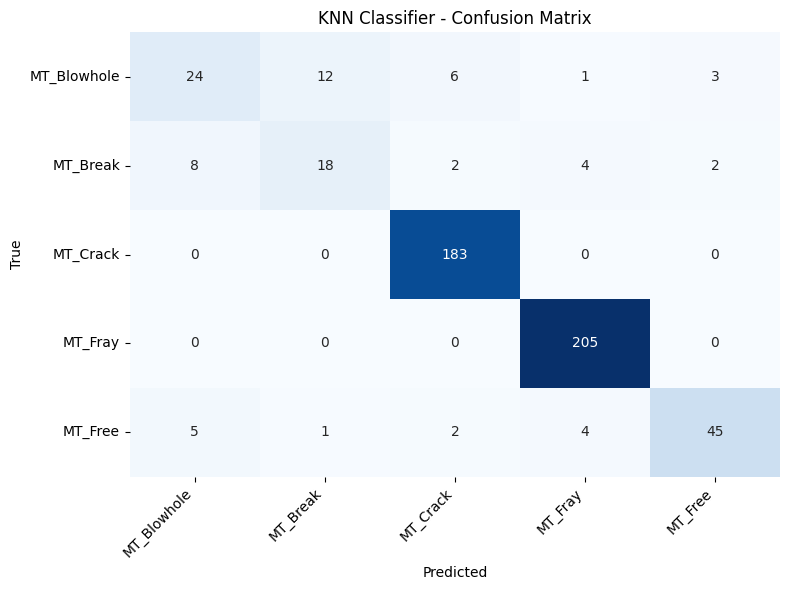

In [14]:
from sklearn.neighbors import KNeighborsClassifier
import os
import joblib

model_path = r"models\knn_classifier.pkl"

# Ensure folder exists
os.makedirs(os.path.dirname(model_path), exist_ok=True)

if os.path.exists(model_path) and os.path.getsize(model_path) > 0:
    knn_clf = joblib.load(model_path)
    predict = knn_clf.predict(x_test)
    calculateMetrics("KNN Classifier", predict, y_test)

else:
    knn_clf = KNeighborsClassifier(
        n_neighbors=5,
        metric="minkowski",  # default (Euclidean when p=2)
        p=2
    )
    knn_clf.fit(x_train, y_train)
    predict = knn_clf.predict(x_test)
    joblib.dump(knn_clf, model_path)
    calculateMetrics("KNN Classifier", predict, y_test)


## Extra_Trees_Classifier


=== Extra Trees Classifier Overall ===
Accuracy  : 94.29%
Precision : 85.83%
Recall    : 84.98%
F1-Score  : 85.30%


=== Classification Report ===
              precision    recall  f1-score   support

 MT_Blowhole       0.71      0.70      0.70        46
    MT_Break       0.69      0.59      0.63        34
    MT_Crack       0.99      1.00      0.99       183
     MT_Fray       1.00      1.00      1.00       205
     MT_Free       0.90      0.96      0.93        57

    accuracy                           0.94       525
   macro avg       0.86      0.85      0.85       525
weighted avg       0.94      0.94      0.94       525



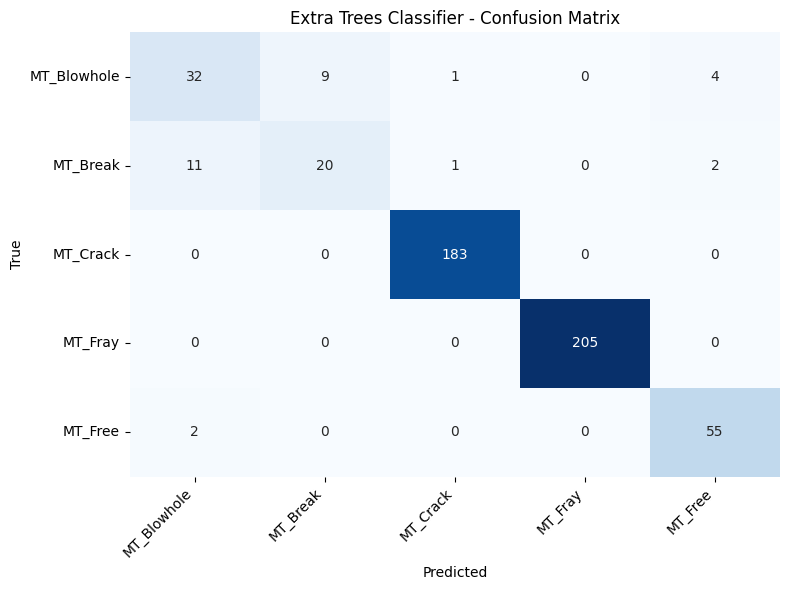

In [15]:
from sklearn.ensemble import ExtraTreesClassifier
import os
import joblib

model_path = r"models\extra_trees_classifier.pkl"

# Ensure folder exists
os.makedirs(os.path.dirname(model_path), exist_ok=True)

if os.path.exists(model_path) and os.path.getsize(model_path) > 0:
    et_clf = joblib.load(model_path)
    predict = et_clf.predict(x_test)
    calculateMetrics("Extra Trees Classifier", predict, y_test)

else:
    et_clf = ExtraTreesClassifier(n_estimators=100,random_state=42,n_jobs=-1)
    et_clf.fit(x_train, y_train)
    predict = et_clf.predict(x_test)
    joblib.dump(et_clf, model_path)
    calculateMetrics("Extra Trees Classifier", predict, y_test)


In [16]:
def create_per_class_dataframes():
    if not metrics_overall:
        print("No models evaluated yet!")
        return None

    overall_df = pd.DataFrame(metrics_overall)
    overall_df = overall_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']]
    
    print("\n" + "="*60)
    print("OVERALL MODEL COMPARISON")
    print("="*60)
    print(overall_df.round(4))
    print()

    class_dfs = {}
    for cls, records in class_metrics_storage.items():
        df = pd.DataFrame(records)
        df = df.set_index('Model')[['Precision', 'Recall', 'F1-Score']]
        
        var_name = cls.replace(" ", "_").replace("-", "_") + "_df"
        globals()[var_name] = df
        class_dfs[cls] = df   # key by original class name (more readable)

        print(f"{cls.upper()} CLASS PERFORMANCE".center(60))
        print("-" * 60)
        print(df.round(4))
        print()

    return overall_df, class_dfs
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 7)

def plot_overall_with_values():
    ax = overall_df.plot(kind='bar', width=0.8, edgecolor='black', alpha=0.9)
    plt.title('Overall Model Performance Comparison', fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Score (%)')
    plt.xlabel('Model')
    plt.ylim(0, 105)
    plt.xticks(rotation=30, ha='right')
    plt.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.grid(axis='y', alpha=0.3)

    # Add values on top of bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f%%', padding=3, fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()


def plot_per_class_metric_universal(metric_name):
    # Reconstruct correct class names from the original storage (universal!)
    class_names = list(class_metrics_storage.keys())  # e.g., ['Cirriform Clouds', 'Clear Sky', ...]
    
    # Build DataFrame: rows = models, columns = clean class names
    data = pd.DataFrame()
    for cls in class_names:
        records = class_metrics_storage[cls]
        df = pd.DataFrame(records).set_index('Model')
        data[cls] = df[metric_name]

    # Ensure same model order as overall_df
    data = data.loc[overall_df.index]

    # Plot
    plt.figure()
    ax = data.plot(kind='bar', width=0.82, edgecolor='black', alpha=0.9)
    
    plt.title(f'{metric_name} per Cloud Class', fontsize=16, fontweight='bold', pad=20)
    plt.ylabel(f'{metric_name} (%)')
    plt.xlabel('Model')
    plt.ylim(0, 105)
    plt.xticks(rotation=30, ha='right')
    plt.legend(title='Cloud Class', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.grid(axis='y', alpha=0.3)

    # Add value labels on top of every bar
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f%%', padding=3, fontsize=9.5, fontweight='bold')

    plt.tight_layout()
    plt.show()

In [17]:
overall_df, class_dfs = create_per_class_dataframes()


OVERALL MODEL COMPARISON
                        Accuracy  Precision  Recall  F1-Score
Model                                                        
Ridge Classifier           48.19      50.22   54.05     45.36
QDA Classifier             56.19      51.97   59.29     50.54
KNN Classifier             90.48      80.71   76.81     78.50
Extra Trees Classifier     94.29      85.83   84.98     85.30

               MT_BLOWHOLE CLASS PERFORMANCE                
------------------------------------------------------------
                        Precision  Recall  F1-Score
Model                                              
Ridge Classifier            26.92   45.65     33.87
QDA Classifier              24.59   65.22     35.71
KNN Classifier              64.86   52.17     57.83
Extra Trees Classifier      71.11   69.57     70.33

                 MT_BREAK CLASS PERFORMANCE                 
------------------------------------------------------------
                        Precision  Recall  F

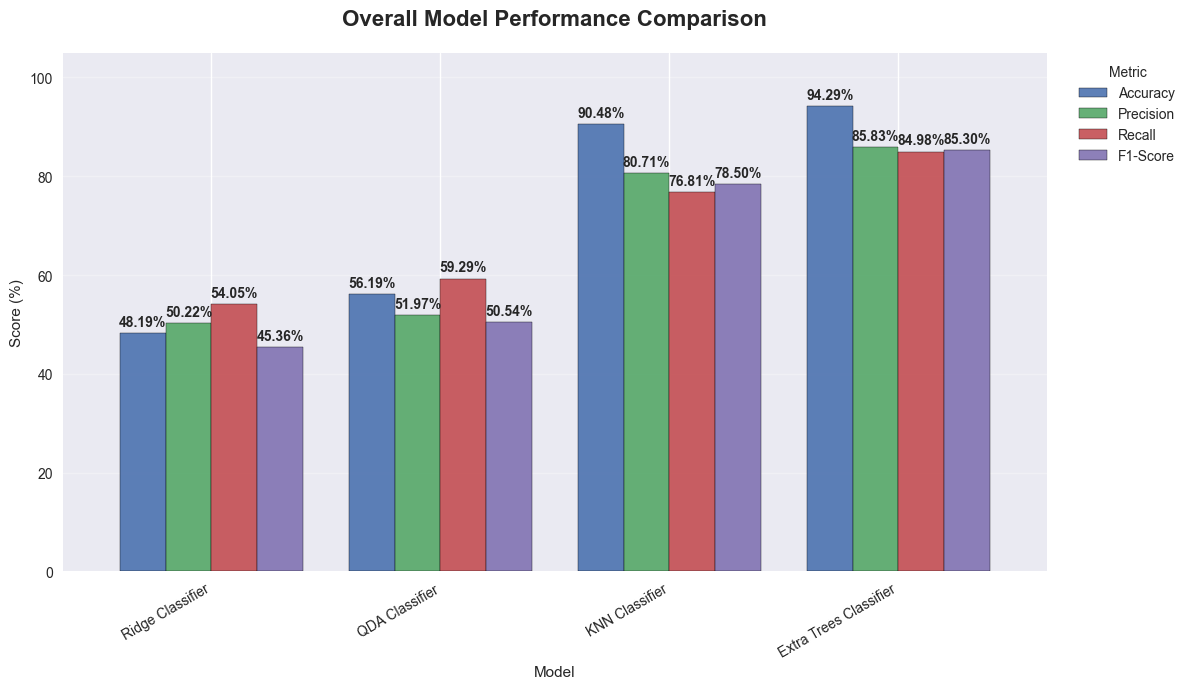

In [18]:
plot_overall_with_values()

<Figure size 1200x700 with 0 Axes>

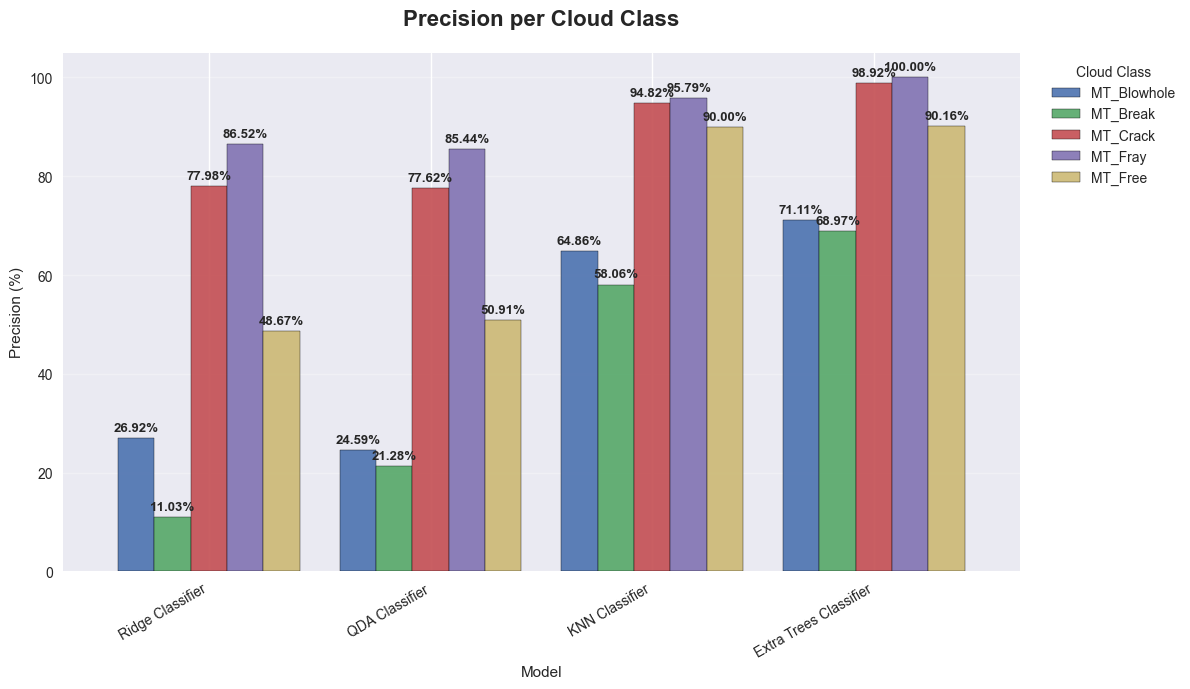

In [19]:
plot_per_class_metric_universal('Precision')

<Figure size 1200x700 with 0 Axes>

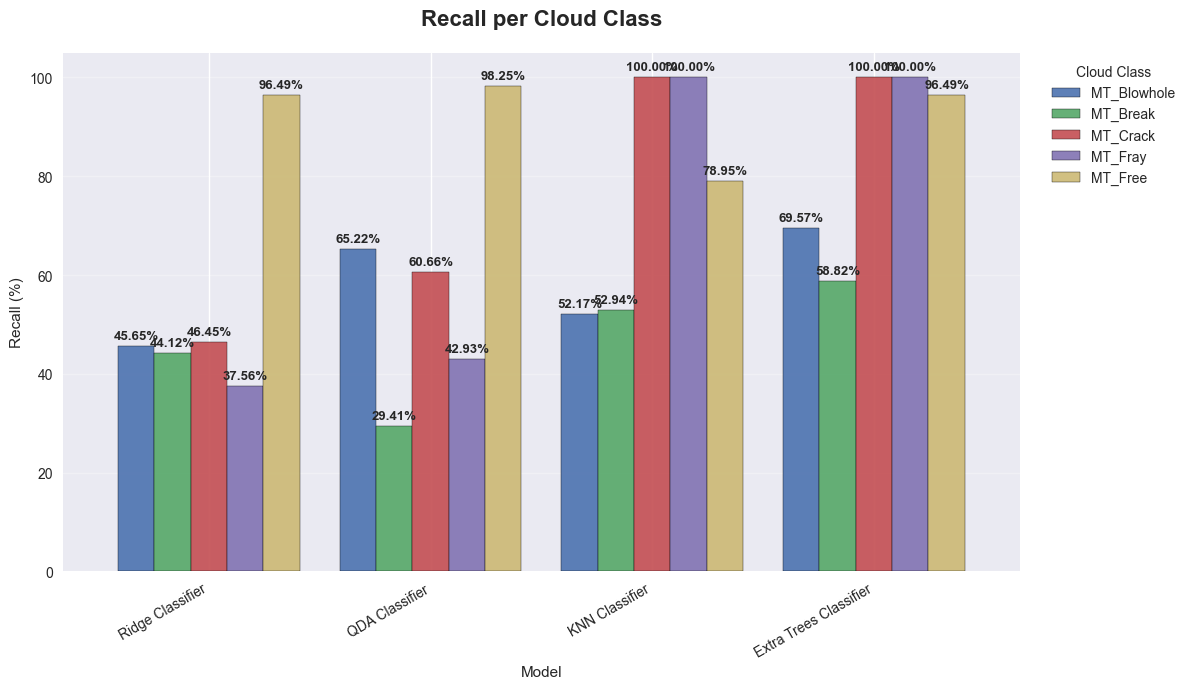

In [20]:
plot_per_class_metric_universal('Recall')

<Figure size 1200x700 with 0 Axes>

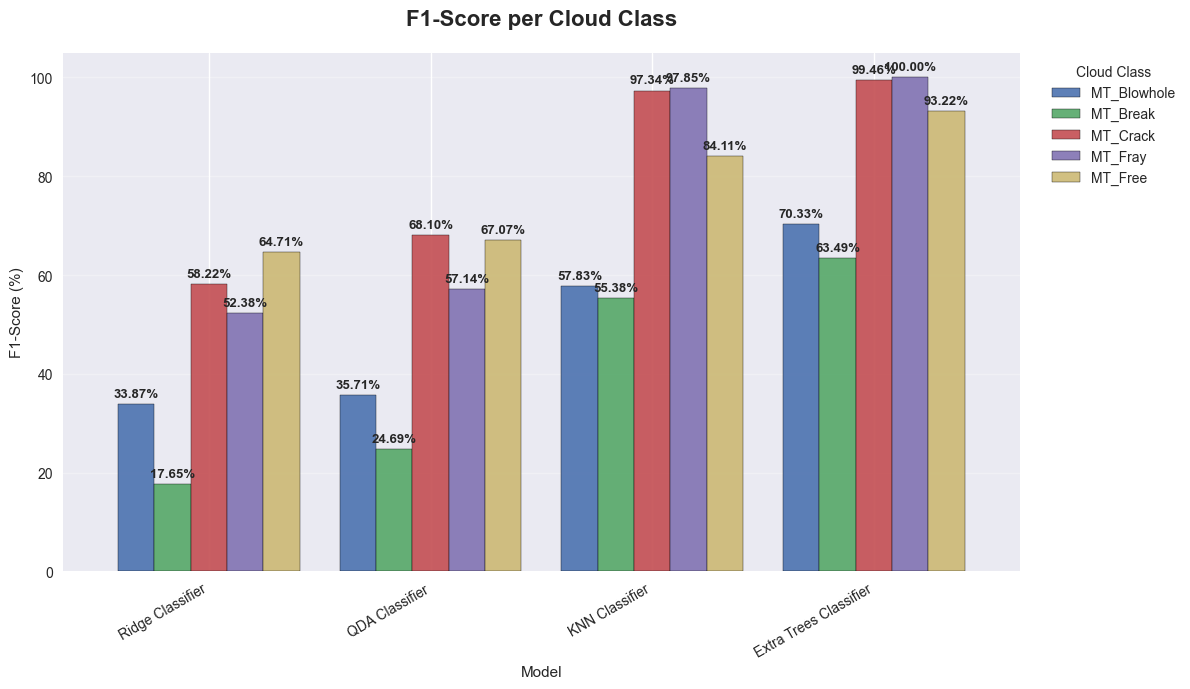

In [21]:
plot_per_class_metric_universal('F1-Score')

## Test_Prediction

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import joblib
from skimage.feature import hog, local_binary_pattern
from tkinter import Tk
from tkinter.filedialog import askopenfilename


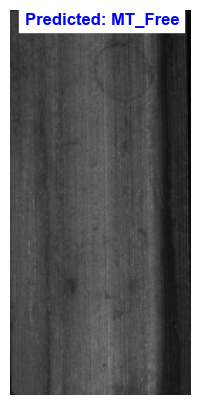

Predicted Class: MT_Free


In [24]:
# ----------------------------
# Prediction function
# ----------------------------
def predict_image(model, categories):
    """Open a file dialog, select an image, and predict its class."""
    
    # Hide root tkinter window
    Tk().withdraw()
    
    # Open file selection dialog
    image_path = askopenfilename(
        title="Select an image",
        filetypes=[("Image files", "*.jpg *.jpeg *.png *.bmp")]
    )
    
    if not image_path:
        print("No image selected.")
        return None

    # Load image safely
    img_array = cv2.imread(image_path)
    if img_array is None:
        print(f"Error: Cannot read the image: {image_path}")
        return None

    # Extract features (resized to IMG_SIZE)
    features = extract_features(img_array).reshape(1, -1)

    # Safety check
    if features.shape[1] != model.n_features_in_:
        raise ValueError(
            f"Feature vector length {features.shape[1]} does not match "
            f"model expected {model.n_features_in_} features."
        )

    # Predict
    pred_idx = model.predict(features)[0]
    pred_label = categories[pred_idx]

    # Display image with predicted label
    plt.figure(figsize=(5,5))
    plt.imshow(cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB))
    plt.text(10, 10, f'Predicted: {pred_label}', color='blue', fontsize=12,
             weight='bold', backgroundcolor='white')
    plt.axis('off')
    plt.show()

    return pred_label

# ----------------------------
# Usage Example
# ----------------------------
# Load trained model
model = joblib.load(r"models\extra_trees_classifier.pkl")

# Predict (opens a file dialog)
predicted_class = predict_image(model, categories)
print("Predicted Class:", predicted_class)